## Utilize flip symmetry to remove node with highest degree

The MaxKcut problem exhibits inherent symmetry concerning the flexibility of relabeling partitions. One approach is to assign the value 0 to a node in set A and 1 if it belongs to set B, or vice versa. This interchange does not alter the cost function associated with the partition. Therefore, we can deduce that the cost function remains invariant when the entire string is flipped.


$C(x)=\sum_{ij}w_{ij}x_{i}(1-x_{j})=\sum_{ij}w_{ij}(1-x_{i})x_{j}$

This symmetry is of course has to be reflected in the quantum problem Hamiltonian

$H_{P}=\sum_{ij}w_{ij}\sigma_{i}^{z}\sigma_{j}^{z}$

and it can be expressed considering the same symmetry: if one flips all the spins the energy cost should remain the same.

The flip operator can be expressed as $M=\otimes_{i} \sigma_{i}^{x}$ and we can check that

$MH_{P}M=H_{P}$

Any problem given in the `class GraphProblem` can utilize this property by setting `fix_one_node = True`

In [12]:
from qaoa import QAOA, problems, mixers, initialstates, utils

In [11]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

Creating problem instance

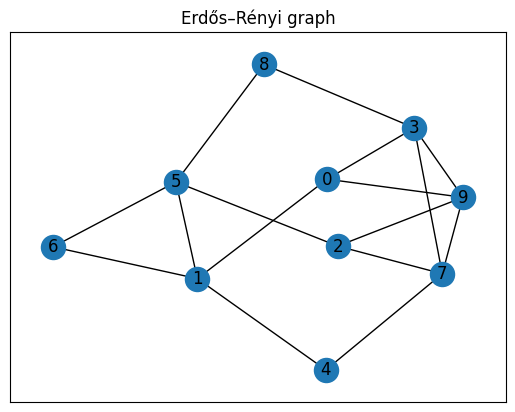

In [3]:
mode = "er"   # options: "house", "er", "regular"

if mode == "house":
    G = nx.house_graph()
    pos = {0: (0, 0), 1: (1, 0), 2: (0, 1), 3: (1, 1), 4: (0.5, 2)}
    nx.draw_networkx(G, pos=pos)
    plt.title("House graph")

elif mode == "er":
    G = nx.read_gml("data/er_n10_k4_0.gml")
    nx.draw_networkx(G)
    plt.title("Erdős–Rényi graph")

elif mode == "regular":
    G = nx.random_regular_graph(3, 10)
    nx.draw_networkx(G)
    plt.title("4-regular random")

Creating a QAOA instance.

In [4]:
qaoa = {}
for fix_one_node in [False, True]:
    problem = problems.MaxKCutBinaryPowerOfTwo(G=G, k_cuts=2,fix_one_node=fix_one_node)
    qaoa[fix_one_node] = QAOA(
        initialstate=initialstates.Plus(),
        problem=problem,
        mixer=mixers.X()
    )
    mincost, maxcost = problem.computeMinMaxCosts()
    print(mincost,maxcost)
    qaoa[fix_one_node].sample_cost_landscape(
        angles={"gamma": [0, np.pi / 2, 10], "beta": [0, np.pi / 2, 10]}
    )

-12 0
2026-03-13 11:45:30 [info     ] Calculating energy landscape for depth p=1... file=qaoa.qaoa func=sample_cost_landscape
2026-03-13 11:45:30 [info     ] Executing sample_cost_landscape file=qaoa.qaoa func=sample_cost_landscape
2026-03-13 11:45:30 [info     ] circuits: 100                  file=qaoa.qaoa func=sample_cost_landscape
2026-03-13 11:45:30 [info     ] Done execute                   file=qaoa.qaoa func=sample_cost_landscape
2026-03-13 11:45:32 [info     ] Done measurement               file=qaoa.qaoa func=sample_cost_landscape
2026-03-13 11:45:32 [info     ] Calculating Energy landscape done file=qaoa.qaoa func=sample_cost_landscape
-12 0
2026-03-13 11:45:32 [info     ] Calculating energy landscape for depth p=1... file=qaoa.qaoa func=sample_cost_landscape
2026-03-13 11:45:32 [info     ] Executing sample_cost_landscape file=qaoa.qaoa func=sample_cost_landscape
2026-03-13 11:45:32 [info     ] circuits: 100                  file=qaoa.qaoa func=sample_cost_landscape
2026-03-

The cost landscape is sampled using angles $\gamma, \beta$ $\in$ $[0, \frac{\pi}{2}]$ on a $10\times10$ grid.

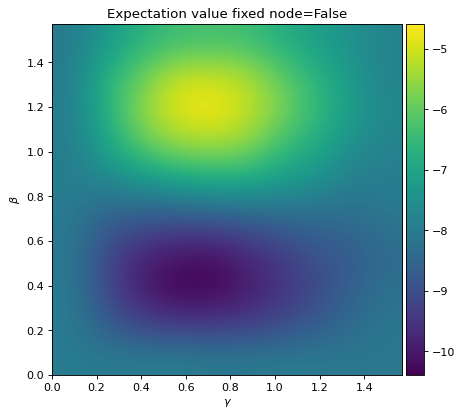

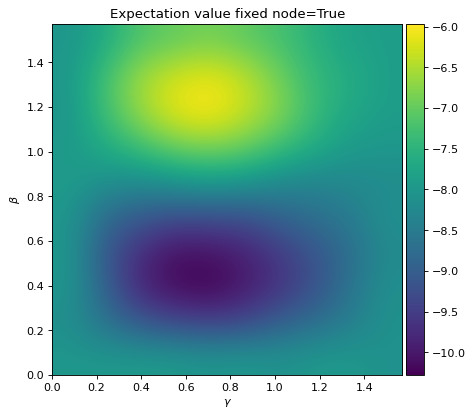

In [5]:
for fix_one_node in [False, True]:
    _=utils.plot_E(qaoa[fix_one_node], title="Expectation value fixed node="+str(fix_one_node))

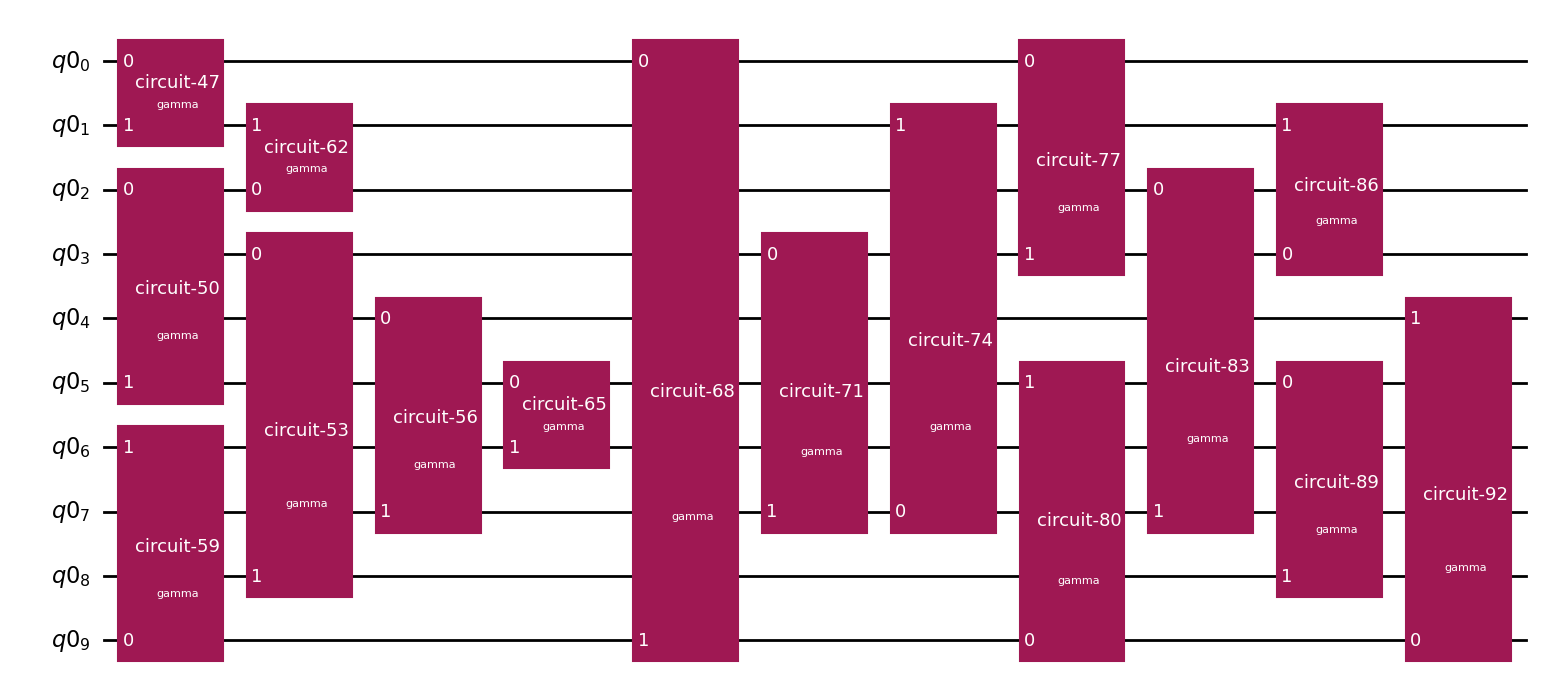

In [6]:
qaoa[False].problem.circuit.draw('mpl')

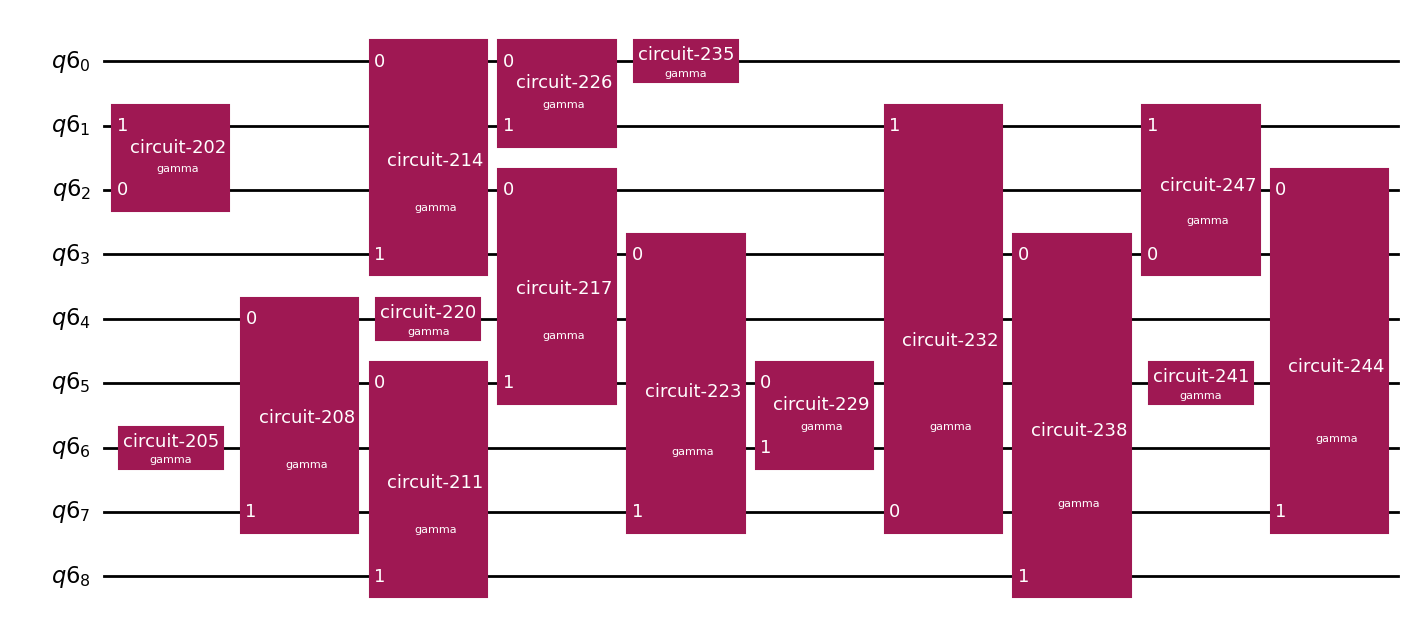

In [7]:
qaoa[True].problem.circuit.draw('mpl')

In [8]:
maxdepth=5
for fix_one_node in [False, True]:
    qaoa[fix_one_node].optimize(depth=maxdepth)

2026-03-13 11:45:35 [info     ] cost(depth 1 = -10.447265625000005 file=qaoa.qaoa func=optimize
2026-03-13 11:45:36 [info     ] cost(depth 2 = -10.963867187500004 file=qaoa.qaoa func=optimize
2026-03-13 11:45:38 [info     ] cost(depth 3 = -11.343749999999996 file=qaoa.qaoa func=optimize
2026-03-13 11:45:40 [info     ] cost(depth 4 = -11.438476562499998 file=qaoa.qaoa func=optimize
2026-03-13 11:45:42 [info     ] cost(depth 5 = -11.5234375     file=qaoa.qaoa func=optimize
2026-03-13 11:45:43 [info     ] cost(depth 1 = -10.338867187500004 file=qaoa.qaoa func=optimize
2026-03-13 11:45:44 [info     ] cost(depth 2 = -11.0078125     file=qaoa.qaoa func=optimize
2026-03-13 11:45:45 [info     ] cost(depth 3 = -11.2060546875  file=qaoa.qaoa func=optimize
2026-03-13 11:45:46 [info     ] cost(depth 4 = -11.403320312499998 file=qaoa.qaoa func=optimize
2026-03-13 11:45:49 [info     ] cost(depth 5 = -11.453124999999998 file=qaoa.qaoa func=optimize


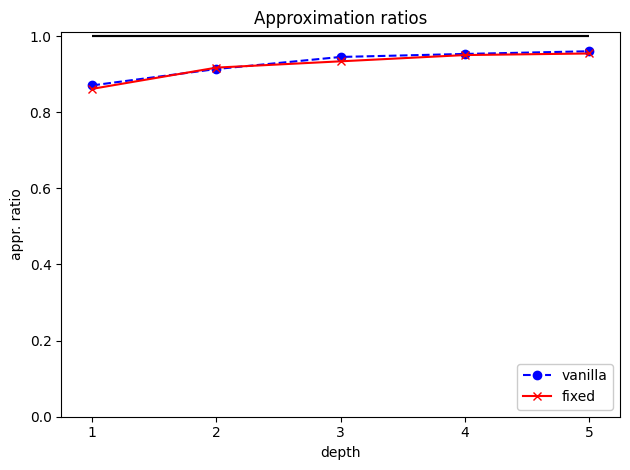

In [9]:
fig = plt.figure()

_=utils.plot_ApproximationRatio(
    qaoa[False], maxdepth,
    mincost=mincost, maxcost=maxcost,
    label=f"vanilla",
    style="o--b",
    fig=fig,
)
_=utils.plot_ApproximationRatio(
    qaoa[True], maxdepth,
    mincost=mincost, maxcost=maxcost,
    label=f"fixed",
    style="x-r",
    fig=fig,
)

plt.title("Approximation ratios")
plt.tight_layout()
plt.show()

## Conclusion

We can remove one qubit and entangling gates equal to the highest degree of the graph. The overall performance remains roughly the same.